# Chapter 6 - String Operations

https://tutswiki.com/pandas-cookbook/chapter6/

In [2]:
import pandas as pd

In [5]:
df = pd.read_csv('weather_2012.csv', parse_dates=['Date/Time'], index_col='Date/Time')
df

,Temp (C),Dew Point Temp (C),Rel Hum (%),Wind Spd (km/h),Visibility (km),Stn Press (kPa),Weather
Date/Time,,,,,,,
2012-01-01 00:00:00,-1.8,-3.9,86,4,8.0,101.24,Fog
2012-01-01 01:00:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2012-01-01 02:00:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
2012-01-01 03:00:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
2012-01-01 04:00:00,-1.5,-3.3,88,7,4.8,101.23,Fog
...,...,...,...,...,...,...,...
2012-12-31 19:00:00,0.1,-2.7,81,30,9.7,100.13,Snow
2012-12-31 20:00:00,0.2,-2.4,83,24,9.7,100.03,Snow
2012-12-31 21:00:00,-0.5,-1.5,93,28,4.8,99.95,Snow


In [7]:
is_snowing = df['Weather'].str.contains('Snow')

In [8]:
is_snowing

Date/Time
2012-01-01 00:00:00    False
2012-01-01 01:00:00    False
2012-01-01 02:00:00    False
2012-01-01 03:00:00    False
2012-01-01 04:00:00    False
                       ...  
2012-12-31 19:00:00     True
2012-12-31 20:00:00     True
2012-12-31 21:00:00     True
2012-12-31 22:00:00     True
2012-12-31 23:00:00     True
Name: Weather, Length: 8784, dtype: bool

In [15]:
df['Temp (C)'].resample('ME').mean()

Date/Time
2012-01-31    -7.371505
2012-02-29    -4.225000
2012-03-31     3.121237
2012-04-30     7.009306
2012-05-31    16.237769
2012-06-30    20.134028
2012-07-31    22.790054
2012-08-31    22.279301
2012-09-30    16.484444
2012-10-31    10.954973
2012-11-30     0.931389
2012-12-31    -3.306317
Freq: ME, Name: Temp (C), dtype: float64

<Axes: xlabel='Date/Time'>

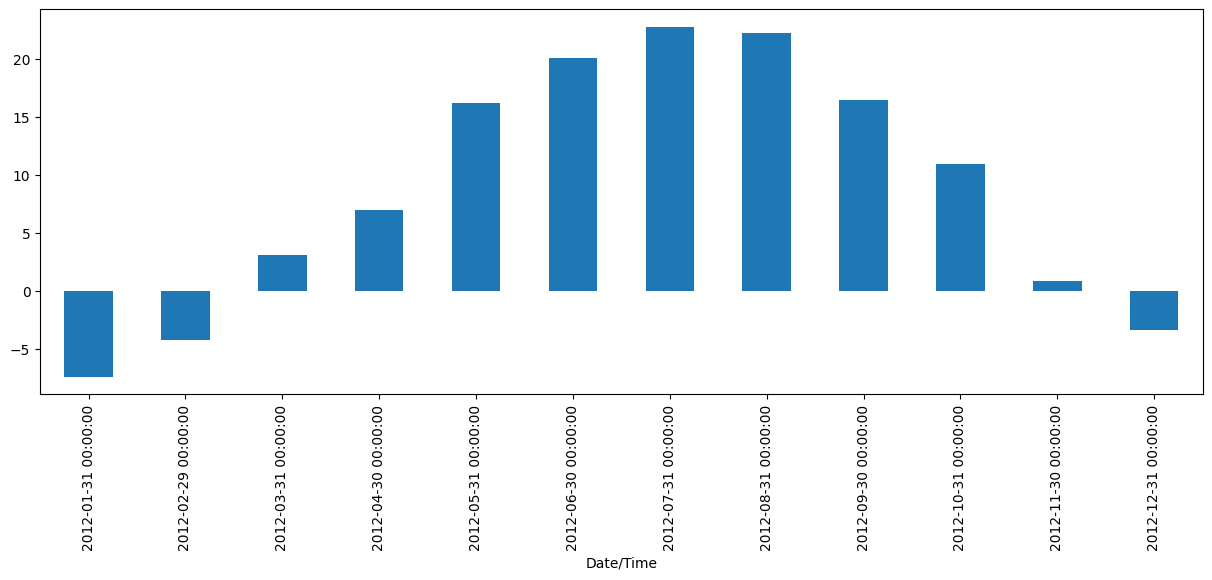

In [22]:
df['Temp (C)'].resample('ME').mean().plot(kind='bar', figsize=(15, 5))

In [19]:
is_snowing.resample('ME').mean()

Date/Time
2012-01-31    0.240591
2012-02-29    0.162356
2012-03-31    0.087366
2012-04-30    0.015278
2012-05-31    0.000000
2012-06-30    0.000000
2012-07-31    0.000000
2012-08-31    0.000000
2012-09-30    0.000000
2012-10-31    0.000000
2012-11-30    0.038889
2012-12-31    0.251344
Freq: ME, Name: Weather, dtype: float64

<Axes: xlabel='Date/Time'>

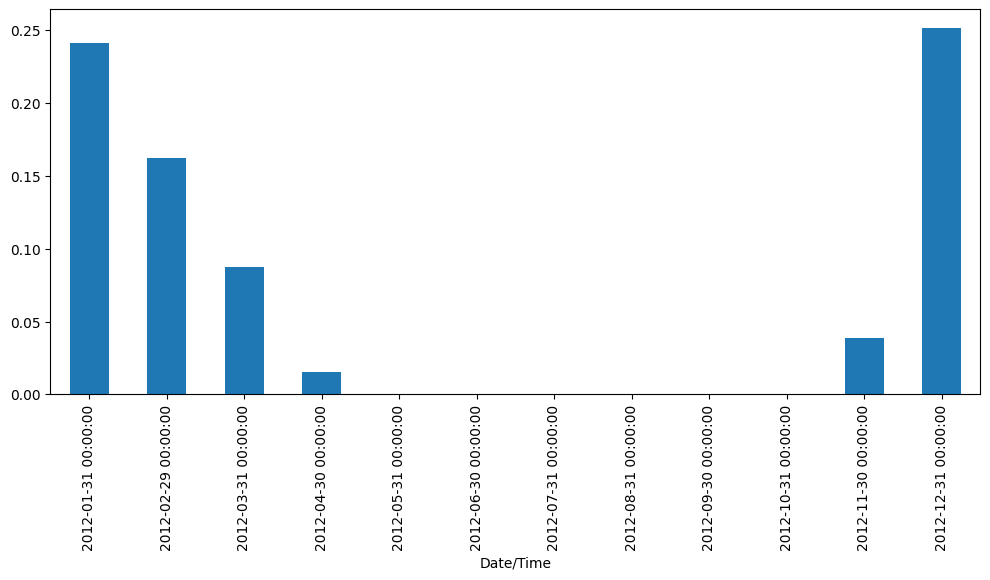

In [21]:
is_snowing.resample('ME').mean().plot(kind='bar', figsize=(12, 5))

In [23]:
temperature = df['Temp (C)'].resample('ME').mean()

In [24]:
snowiness = is_snowing.resample('ME').mean()

In [26]:
temperature.name = "Temperature"
snowiness.name = "Snowiness"
stats = pd.concat([temperature, snowiness], axis=1)
stats

,Temperature,Snowiness
Date/Time,,
2012-01-31,-7.371505,0.240591
2012-02-29,-4.225000,0.162356
2012-03-31,3.121237,0.087366
2012-04-30,7.009306,0.015278
2012-05-31,16.237769,0.000000
2012-06-30,20.134028,0.000000
2012-07-31,22.790054,0.000000
2012-08-31,22.279301,0.000000
2012-09-30,16.484444,0.000000


array([<Axes: title={'center': 'Temperature'}, xlabel='Date/Time'>,
       <Axes: title={'center': 'Snowiness'}, xlabel='Date/Time'>],
      dtype=object)

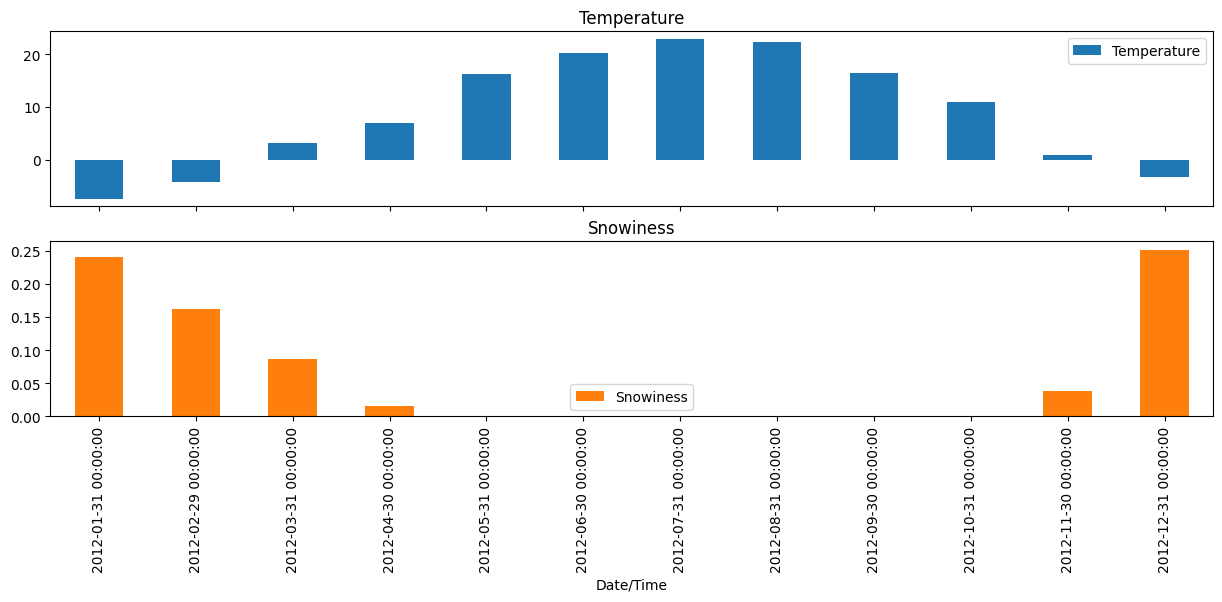

In [28]:
stats.plot(kind='bar', subplots=True, figsize=(15, 5))